# Hola &#x1F600;,

Soy **Hesus Garcia** – **"Soy el único Hesus que conoces (y probablemente conocerás) 🌟"** – Sí, como "Jesús", pero con una H que me hace único. Puede sonar raro, pero créeme, ¡no lo olvidarás! Como tu revisor en Triple-Ten, estoy aquí para guiarte y ayudarte a mejorar tu código. Si algo necesita un ajuste, no hay de qué preocuparse; ¡aquí estoy para hacer que tu trabajo brille con todo su potencial! ✨

Cada vez que encuentre un detalle importante en tu código, te lo señalaré para que puedas corregirlo y así te prepares para un ambiente de trabajo real, donde el líder de tu equipo actuaría de manera similar. Si en algún momento no logras solucionar el problema, te daré más detalles para ayudarte en nuestra próxima oportunidad de revisión.

Es importante que cuando encuentres un comentario, **no los muevas, no los modifiques, ni los borres**.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> - ¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis de datos o al proyecto. Continúa aplicando estas buenas prácticas en futuras secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Este código está correcto, pero se puede optimizar. Considera implementar mejoras para que sea más eficiente y fácil de leer. Esto fortalecerá la calidad de tu proyecto.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error en el código que es necesario corregir para aprobar esta sección. Por favor, revisa y corrige este punto, ya que es fundamental para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto.
- **Áreas de mejora:** Sugerencias sobre aspectos donde puedes mejorar.
- **Temas adicionales para investigar:** Ideas de temas opcionales que puedes explorar por tu cuenta para desarrollar aún más tus habilidades.

Estos temas adicionales no son obligatorios en esta etapa, pero pueden serte útiles para profundizar en el futuro.

---


Esta estructura en viñetas facilita la lectura y comprensión de cada parte del comentario final.

También puedes responderme de la siguiente manera si tienes alguna duda o quieres aclarar algo específico:


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>


**¡Empecemos!** &#x1F680;


# Proyecto 10. Tienda online.

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import shapiro
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

In [67]:
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

#### Limpieza de datos. 

In [47]:
hypotheses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


In [48]:
print(hypotheses.head())

                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   Confidence  Effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1  


In [68]:
hypotheses.columns = hypotheses.columns.str.strip().str.lower().str.replace(" ", "_")
print(hypotheses.columns)

Index(['hypothesis', 'reach', 'impact', 'confidence', 'effort'], dtype='object')


In [50]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB


In [51]:
print(orders.head())

   transactionId   visitorId        date  revenue group
0     3667963787  3312258926  2019-08-15     30.4     B
1     2804400009  3642806036  2019-08-15     15.2     B
2     2961555356  4069496402  2019-08-15     10.2     A
3     3797467345  1196621759  2019-08-15    155.1     B
4     2282983706  2322279887  2019-08-15     40.5     B


In [69]:
orders.columns = orders.columns.str.strip().str.lower().str.replace(" ", "_")
print(orders.columns)

Index(['transactionid', 'visitorid', 'date', 'revenue', 'group'], dtype='object')


In [70]:
orders['date'] = pd.to_datetime(orders['date'])

In [78]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [79]:
print(visits.head())

         date group  visits
0  2019-08-01     A     719
1  2019-08-02     A     619
2  2019-08-03     A     507
3  2019-08-04     A     717
4  2019-08-05     A     756


In [71]:
visits.columns = visits.columns.str.strip().str.lower().str.replace(" ", "_")
print(visits.columns)

Index(['date', 'group', 'visits'], dtype='object')


In [72]:
visits['date'] = pd.to_datetime(visits['date'])

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - Muy buena apertura del proyecto: la carga y limpieza inicial de datos está organizada y muestra un manejo claro de Pandas. Continúa con esta solidez en las siguientes etapas del análisis.
</div>


## Priorizar hipótesis. 

### Aplicar el framework ICE

In [73]:
max_effort = hypotheses['effort'].max()
hypotheses['ease'] = max_effort - hypotheses['effort'] + 1

print("Verificación de la conversión:")
print(hypotheses[['hypothesis', 'effort', 'ease']].head())

Verificación de la conversión:
                                          hypothesis  effort  ease
0  Add two new channels for attracting traffic. T...       6     5
1  Launch your own delivery service. This will sh...      10     1
2  Add product recommendation blocks to the store...       3     8
3  Change the category structure. This will incre...       8     3
4  Change the background color on the main page. ...       1    10


In [74]:
hypotheses['ice_score'] = hypotheses['impact'] * hypotheses['confidence'] * hypotheses['ease']

print("Primeras 5 hipótesis con puntaje ICE:")
print(hypotheses[['hypothesis', 'ice_score']].sort_values('ice_score', ascending=False).head())

Primeras 5 hipótesis con puntaje ICE:
                                          hypothesis  ice_score
8  Launch a promotion that gives users discounts ...        486
0  Add two new channels for attracting traffic. T...        400
7  Add a subscription form to all the main pages....        336
6  Show banners with current offers and sales on ...        192
2  Add product recommendation blocks to the store...        168


##### La hipótesis con el puntaje más alto es la que implica realizar promociones su puntaje ice es el más alto, pero aun así necesitamos más datos para llevar a cabo la hipótesis

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La aplicación del framework ICE está bien ejecutada y refleja una comprensión clara del cálculo y la priorización. Presentas los resultados de forma ordenada y tu interpretación inicial muestra buen criterio analítico.
</div>


### Aplicar el framework RICE

In [75]:
hypotheses['rice_score'] = hypotheses['reach'] * hypotheses['impact'] * hypotheses['confidence'] * hypotheses['ease']
print("primeras 5 hipótesis con puntaje RICE")
print(hypotheses[['hypothesis', 'rice_score']].sort_values('rice_score', ascending=False).head())

primeras 5 hipótesis con puntaje RICE
                                          hypothesis  rice_score
7  Add a subscription form to all the main pages....        3360
2  Add product recommendation blocks to the store...        1344
0  Add two new channels for attracting traffic. T...        1200
6  Show banners with current offers and sales on ...         960
8  Launch a promotion that gives users discounts ...         486


##### La hipótesis que se encuentra en el número uno ofrece aplicar formularios esto puede ser una buena opción, pero difícil de aplicar aun así necesitamos más datos para saber si es viable llevar el gasto en la aplicación de la hipótesis.

###  Cómo cambia la priorización de hipótesis cuando utilizas RICE en lugar de ICE

In [76]:
ice_ranking = hypotheses[['hypothesis', 'ice_score']].sort_values('ice_score', ascending=False).reset_index(drop=True)
ice_ranking['ice_rank'] = range(1, len(ice_ranking) + 1)

rice_ranking = hypotheses[['hypothesis', 'rice_score']].sort_values('rice_score', ascending=False).reset_index(drop=True)
rice_ranking['rice_rank'] = range(1, len(rice_ranking) + 1)

print("Ranking ICE:")
print(ice_ranking)
print("Ranking RICE:")
print(rice_ranking)

Ranking ICE:
                                          hypothesis  ice_score  ice_rank
0  Launch a promotion that gives users discounts ...        486         1
1  Add two new channels for attracting traffic. T...        400         2
2  Add a subscription form to all the main pages....        336         3
3  Show banners with current offers and sales on ...        192         4
4  Add product recommendation blocks to the store...        168         5
5  Add a customer review page. This will increase...         32         6
6  Change the category structure. This will incre...         27         7
7  Launch your own delivery service. This will sh...         20         8
8  Change the background color on the main page. ...         10         9
Ranking RICE:
                                          hypothesis  rice_score  rice_rank
0  Add a subscription form to all the main pages....        3360          1
1  Add product recommendation blocks to the store...        1344          2
2  Ad

In [77]:
comparison = pd.merge(ice_ranking[['hypothesis', 'ice_score', 'ice_rank']], 
                     rice_ranking[['hypothesis', 'rice_score', 'rice_rank']], 
                     on='hypothesis')

comparison['rank_change'] = comparison['ice_rank'] - comparison['rice_rank']

print("Comparación ICE vs RICE:")
print(comparison[['hypothesis', 'ice_rank', 'rice_rank', 'rank_change']].head(10))

Comparación ICE vs RICE:
                                          hypothesis  ice_rank  rice_rank  \
0  Launch a promotion that gives users discounts ...         1          5   
1  Add two new channels for attracting traffic. T...         2          3   
2  Add a subscription form to all the main pages....         3          1   
3  Show banners with current offers and sales on ...         4          4   
4  Add product recommendation blocks to the store...         5          2   
5  Add a customer review page. This will increase...         6          7   
6  Change the category structure. This will incre...         7          6   
7  Launch your own delivery service. This will sh...         8          8   
8  Change the background color on the main page. ...         9          9   

   rank_change  
0           -4  
1           -1  
2            2  
3            0  
4            3  
5           -1  
6            1  
7            0  
8            0  


##### Podemos observar que las tres primeras hipótesis son las mismas en un ranking que en el otro solo cambia el puesto y en general el top 10 solo varía en la posición esto se puede deber a que en rice se utiliza reach un reach más alto puede impulsar unas hipótesis y bajar de puesto a otras.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - Muy buena aplicación del framework RICE y comparación con ICE; presentas los cálculos, rankings y la interpretación de forma clara. Tu análisis muestra solidez al identificar cómo el factor reach modifica la priorización.
</div>


## Análisis del test A/B.

### Ingreso acumulado por grupo

In [78]:
daily_revenue = orders.groupby(['date', 'group'])['revenue'].sum().reset_index()
daily_revenue = daily_revenue.sort_values(['group', 'date'])

daily_revenue['cumulative_revenue'] = daily_revenue.groupby('group')['revenue'].cumsum()

print(daily_revenue.head())

        date group  revenue  cumulative_revenue
0 2019-08-01     A   2356.8              2356.8
2 2019-08-02     A   1503.5              3860.3
4 2019-08-03     A   1815.2              5675.5
6 2019-08-04     A   1146.6              6822.1
8 2019-08-05     A   1988.1              8810.2


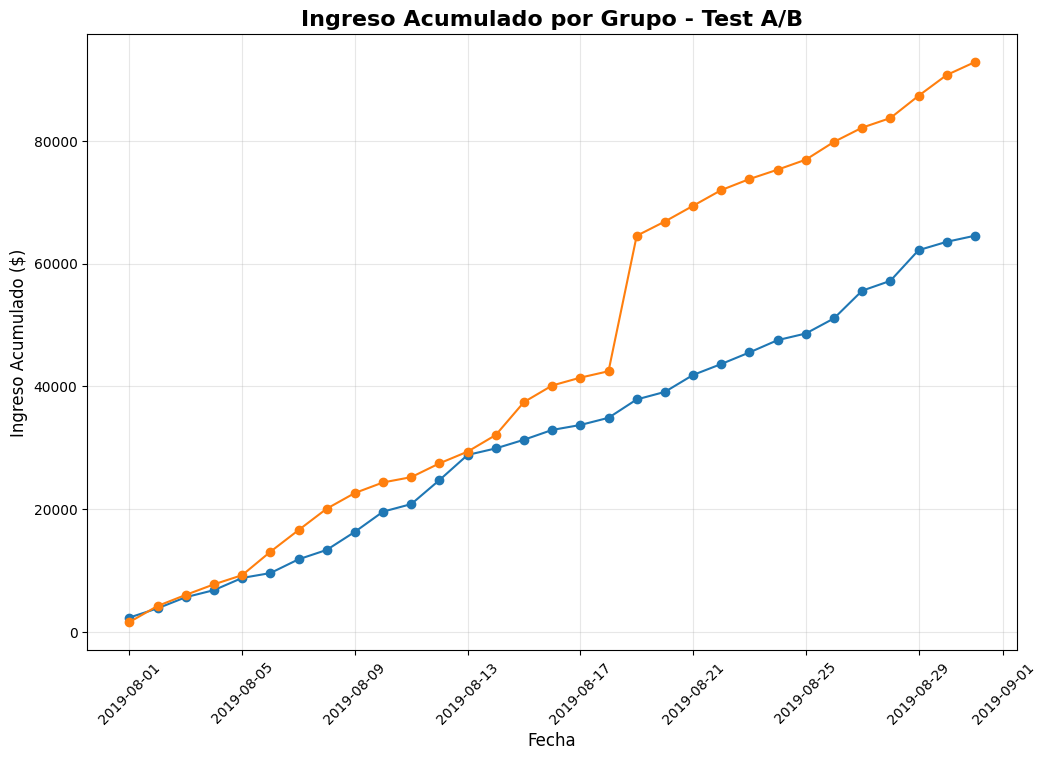

In [79]:
plt.figure(figsize=(12, 8))
for group in daily_revenue['group'].unique():
    group_data = daily_revenue[daily_revenue['group'] == group]
    plt.plot(group_data['date'], group_data['cumulative_revenue'], marker='o')

plt.title('Ingreso Acumulado por Grupo - Test A/B', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Ingreso Acumulado ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

In [80]:
final_stats = daily_revenue.groupby('group')['cumulative_revenue'].last().reset_index()
final_stats.columns = ['group', 'total_revenue']
print("Ingreso total por grupo:")
print(final_stats)

diff = final_stats.loc[1, 'total_revenue'] - final_stats.loc[0, 'total_revenue']
print(f" Diferencia entre grupos: ${diff:.2f}")

Ingreso total por grupo:
  group  total_revenue
0     A        64554.9
1     B        92840.6
 Diferencia entre grupos: $28285.70


##### Podemos ver como hay una diferencia significativa entre un grupo y otro, pero las ganancias son constantes en ambos grupos esto es algo bueno para la tienda en línea.

### El tamaño de pedido promedio acumulado por grupo.

In [81]:
daily_avg_order = orders.groupby(['date', 'group'])['revenue'].mean().reset_index()
daily_avg_order.columns = ['date', 'group', 'avg_order_size']
daily_avg_order = daily_avg_order.sort_values(['group', 'date'])

daily_avg_order['cumulative_avg_order'] = daily_avg_order.groupby('group')['avg_order_size'].expanding().mean().reset_index(level=0, drop=True)

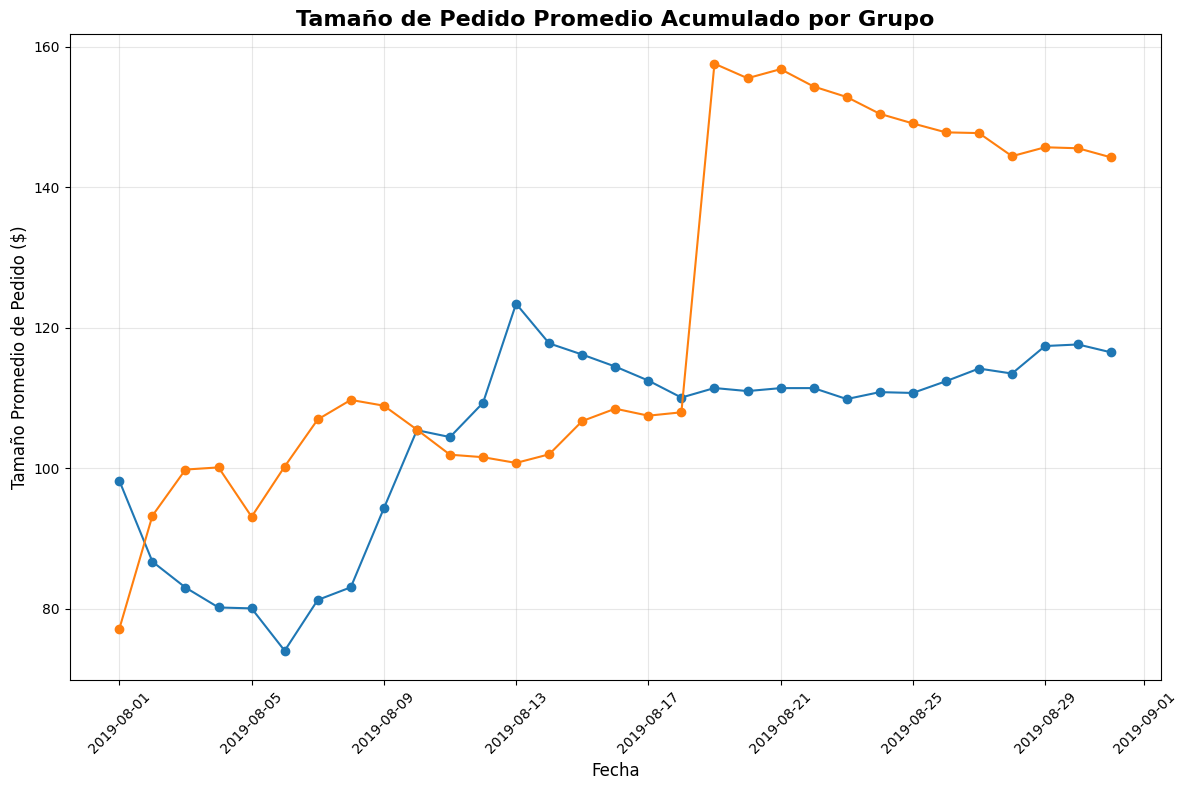

In [82]:
plt.figure(figsize=(12, 8))

for group in daily_avg_order['group'].unique():
    group_data = daily_avg_order[daily_avg_order['group'] == group]
    plt.plot(group_data['date'], group_data['cumulative_avg_order'], 
             marker='o')
plt.title('Tamaño de Pedido Promedio Acumulado por Grupo', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Tamaño Promedio de Pedido ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Los pedidos del grupo A son más constantes, pero los del grupo B se incrementan constantemente hasta después de octubre que representan una caída tenemos que analizar el porqué, pero esto requiere un análisis más profundo.

### La diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A. 

In [83]:
comparison_data = daily_avg_order.pivot(index='date', 
                                       columns='group', 
                                       values='cumulative_avg_order')
print(comparison_data.head())

group               A           B
date                             
2019-08-01  98.200000   77.142857
2019-08-02  86.687500   93.233929
2019-08-03  83.002778   99.797619
2019-08-04  80.167708  100.102626
2019-08-05  80.038967   93.082101


In [84]:
comparison_data['relative_difference'] = (comparison_data['B'] - comparison_data['A']) / comparison_data['A'] * 100
print(comparison_data.head())

group               A           B  relative_difference
date                                                  
2019-08-01  98.200000   77.142857           -21.443119
2019-08-02  86.687500   93.233929             7.551756
2019-08-03  83.002778   99.797619            20.234071
2019-08-04  80.167708  100.102626            24.866518
2019-08-05  80.038967   93.082101            16.295980


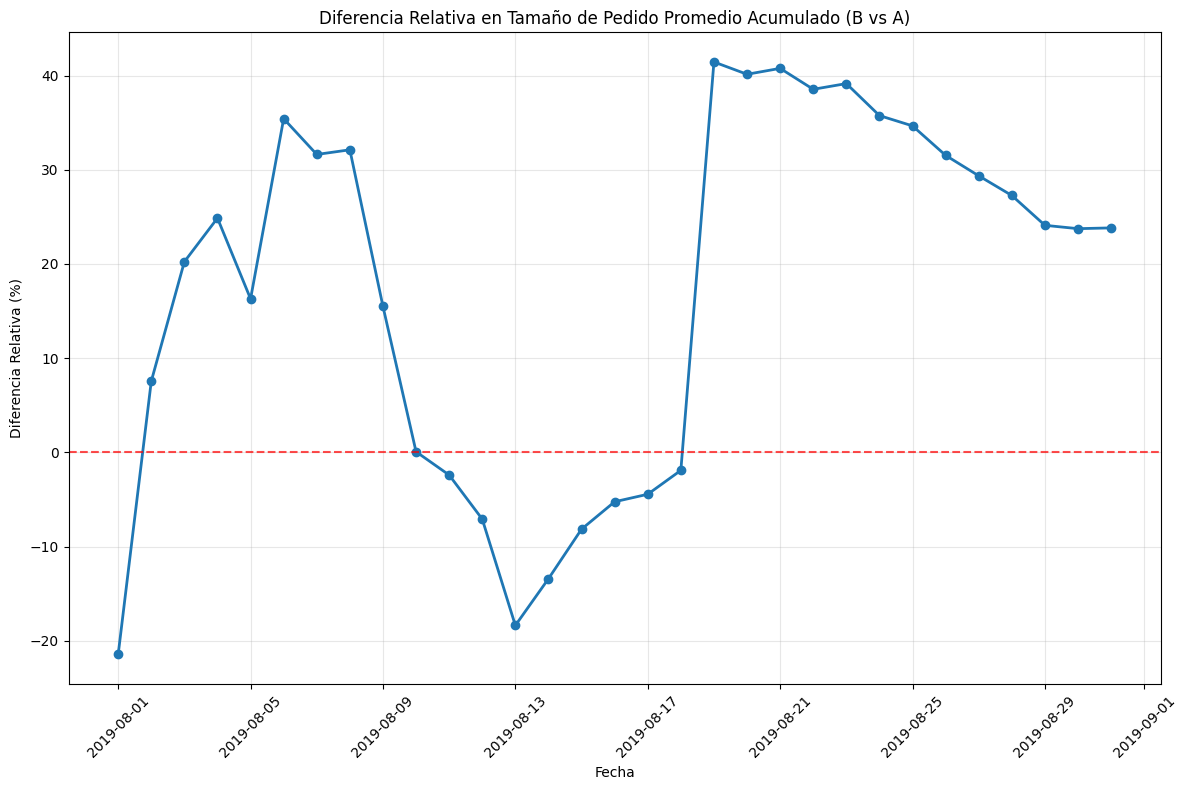

In [85]:
plt.figure(figsize=(12, 8))
plt.plot(comparison_data.index, comparison_data['relative_difference'], 
         marker='o', linewidth=2)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.title('Diferencia Relativa en Tamaño de Pedido Promedio Acumulado (B vs A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia Relativa (%)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Podemos ver que el primer día de pedidos el grupo B tiene un 21.44% de promedio más pequeño que el A, pero esto cambia en los siguientes días los pedidos del grupo B empiezan a ser mayores, podemos concluir con estos datos que el grupo B tiene pedidos más grandes normalmente podemos analizar más a profundidad el porqué pasa esto podríamos dar hipótesis de esto como que los clientes del grupo B son para empresas con alto consumo de productos y el Grupo A pueden ser para uso personal, pero es necesario más datos para averiguar esto, puedo sugerir un apartado en el registro para verificar con que fin se utilizan los productos solicitados y así poder dar promociones o incentivos por el tamaño de la compra o número de productos.

### Tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día.

In [86]:
daily_orders = orders.groupby(['date', 'group']).size().reset_index(name='orders')
print(daily_orders.head())

        date group  orders
0 2019-08-01     A      24
1 2019-08-01     B      21
2 2019-08-02     A      20
3 2019-08-02     B      24
4 2019-08-03     A      24


In [87]:
conversion_data = pd.merge(visits, daily_orders, on=['date', 'group'], how='left')
conversion_data['orders'] = conversion_data['orders'].fillna(0)
print(conversion_data.head())

        date group  visits  orders
0 2019-08-01     A     719      24
1 2019-08-02     A     619      20
2 2019-08-03     A     507      24
3 2019-08-04     A     717      16
4 2019-08-05     A     756      25


In [88]:
conversion_data['tasa'] = (conversion_data['orders'] / conversion_data['visits']) * 100

print(conversion_data.head().sort_values('tasa', ascending=False))

        date group  visits  orders      tasa
2 2019-08-03     A     507      24  4.733728
0 2019-08-01     A     719      24  3.337969
4 2019-08-05     A     756      25  3.306878
1 2019-08-02     A     619      20  3.231018
3 2019-08-04     A     717      16  2.231520


In [89]:
orders_per_user = orders.groupby('visitorid').size().reset_index(name='num_orders')
print(orders_per_user.head(10))

   visitorid  num_orders
0    5114589           1
1    6958315           1
2    8300375           2
3   11685486           1
4   39475350           1
5   47206413           1
6   48147722           1
7   54447517           1
8   56960363           1
9   66685450           1


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - Presentas un análisis detallado del test A/B, construyendo métricas acumuladas, visualizaciones claras y conclusiones bien fundamentadas. Tu lectura de las diferencias entre grupos muestra un buen manejo interpretativo y refuerza la solidez del análisis.
</div>


### Tasas de conversión diarias de los dos grupos.

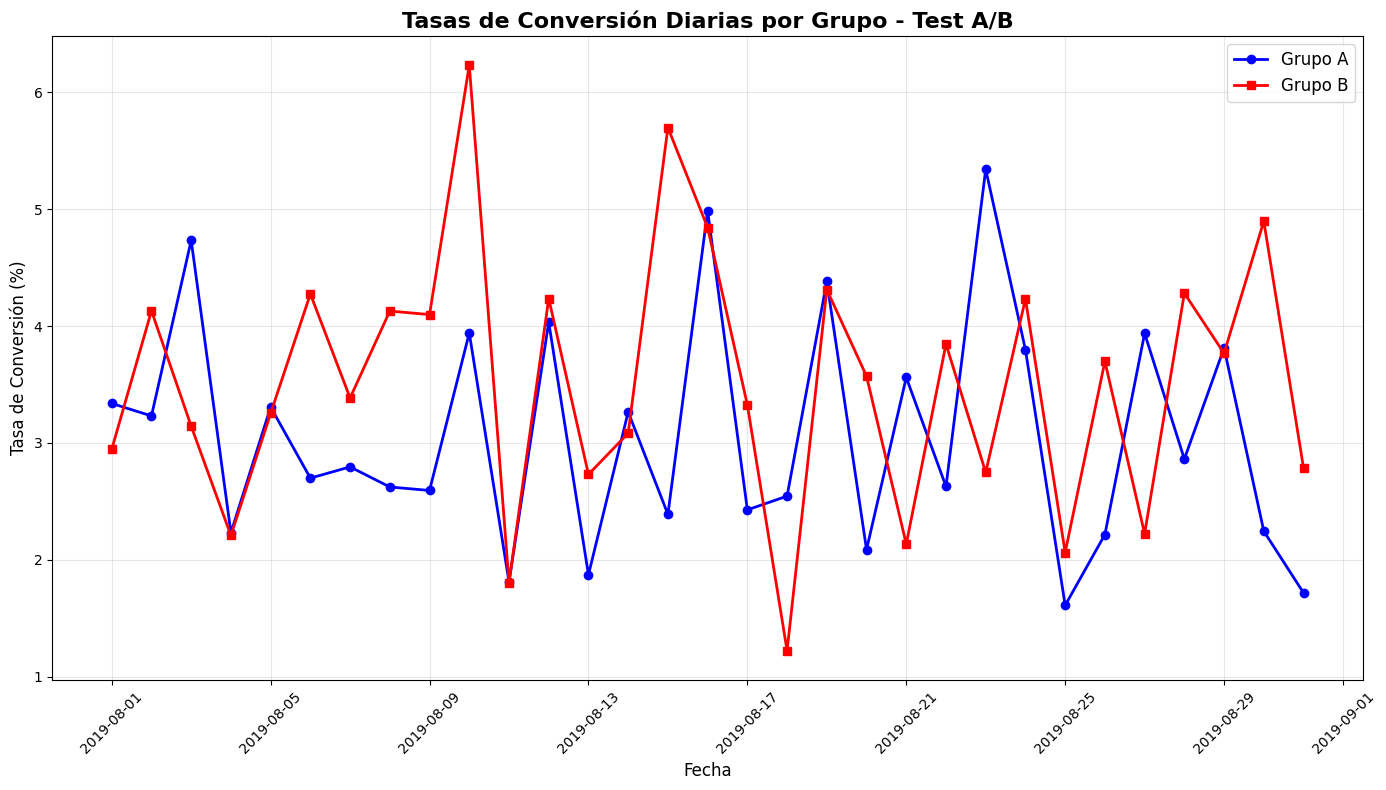

In [90]:
plt.figure(figsize=(14, 8))

group_a = conversion_data[conversion_data['group'] == 'A']
group_b = conversion_data[conversion_data['group'] == 'B']

plt.plot(group_a['date'], group_a['tasa'], marker='o', linewidth=2, label='Grupo A', color='blue')
plt.plot(group_b['date'], group_b['tasa'], marker='s', linewidth=2, label='Grupo B', color='red')

plt.title('Tasas de Conversión Diarias por Grupo - Test A/B', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Tasa de Conversión (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Por un lado podemos notar que la tasa de conversión por usuario en la mayoría de los casos suele ser muy baja, ya que en la mayoría de los casos hay muchas visitas y pocas órdenes necesitamos buscar que es lo que afecta que no terminen de realizar su orden necesitamos el análisis más amplio especificado en porque no se realizan las órdenes.

##### Como grupo no podemos dar un claro análisis porque, como podemos notar en el gráfico, los grupos tienen tendencias a subir de pedidos o bajar el número de órdenes. Una vez más, necesitamos más datos para completar el analisis y poder dar una forma de incrementar las ventas.

### Numero de pedidos por usuario.

In [91]:
orders_per_user = orders.groupby('visitorid').size().reset_index(name='num_orders')
print(orders_per_user.head(10))

distribution = orders_per_user['num_orders'].value_counts().sort_index()
print("Distribución de usuarios por número de pedidos:")
print(distribution)

   visitorid  num_orders
0    5114589           1
1    6958315           1
2    8300375           2
3   11685486           1
4   39475350           1
5   47206413           1
6   48147722           1
7   54447517           1
8   56960363           1
9   66685450           1
Distribución de usuarios por número de pedidos:
1     937
2      64
3      17
4       3
5       6
8       1
9       1
11      2
Name: num_orders, dtype: int64


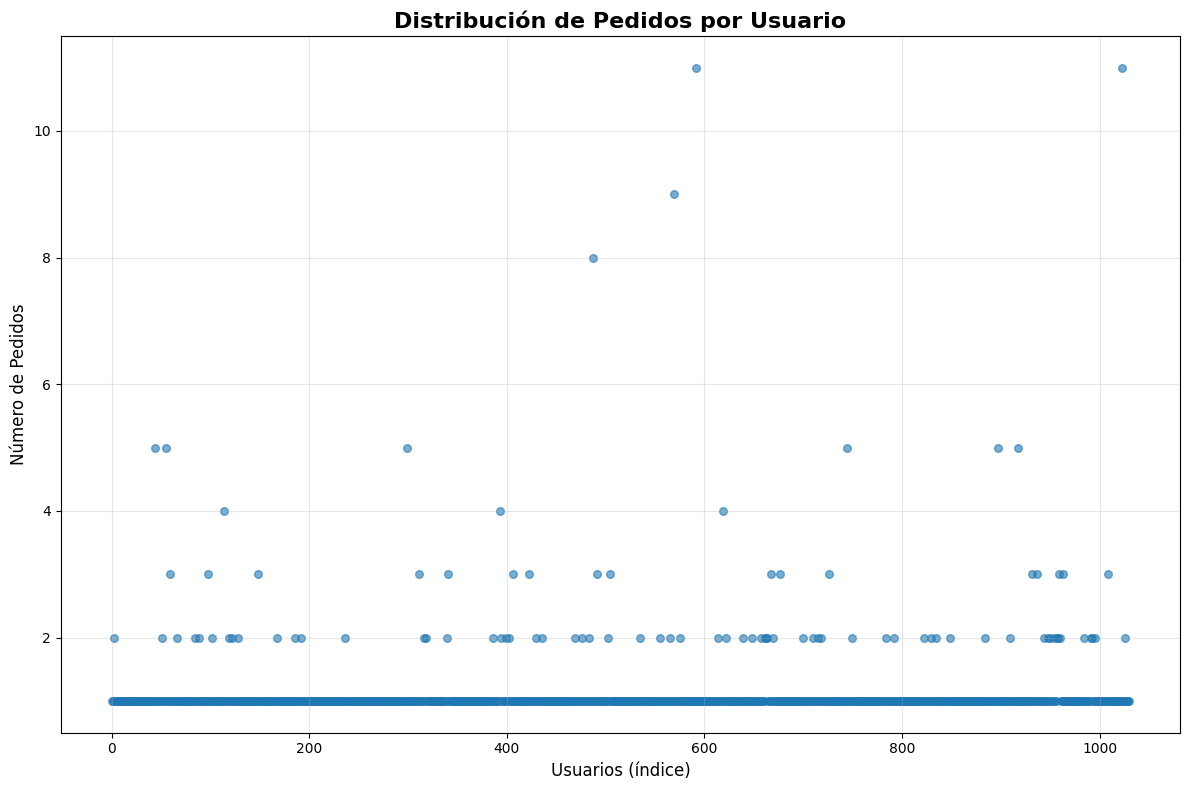

In [92]:
plt.figure(figsize=(12, 8))

user_indices = range(len(orders_per_user))

plt.scatter(user_indices, orders_per_user['num_orders'], alpha=0.6, s=30)
plt.title('Distribución de Pedidos por Usuario', fontsize=16, fontweight='bold')
plt.xlabel('Usuarios (índice)', fontsize=12)
plt.ylabel('Número de Pedidos', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### La distribución de pedidos por usuario confirma lo que ya vimos, la mayoría de los usuarios no concluyen sus órdenes y solo el 10% tiene más de una orden, tal vez el formato de solicitud sea algo complicado de llenar o no hay la variedad de productos buscados, necesitamos una encuesta para confirmar estos datos.

### Percentil del 95 y 99 de los precios de los pedidos

In [93]:
percentile_95 = np.percentile(orders_per_user['num_orders'], 95)
percentile_99 = np.percentile(orders_per_user['num_orders'], 99)

print(f"Percentil 95: {percentile_95}")
print(f"Percentil 99: {percentile_99}")

# Estadísticas adicionales para contexto
print(f"\nEstadísticas descriptivas:")
print(orders_per_user['num_orders'].describe())

Percentil 95: 2.0
Percentil 99: 4.0

Estadísticas descriptivas:
count    1031.000000
mean        1.161009
std         0.724919
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        11.000000
Name: num_orders, dtype: float64


##### Con esto podemos observar que el percentil es muy bajo, lo que confirma que muy pocos usuarios hacen más de una orden.

In [94]:
anomaly_threshold = percentile_95  

print(f"Punto de anomalía definido en: {anomaly_threshold} pedidos")

anomalous_users = orders_per_user[orders_per_user['num_orders'] > anomaly_threshold]
print(f"Número de usuarios anómalos (>{anomaly_threshold} pedidos): {len(anomalous_users)}")
print(f"Porcentaje de usuarios anómalos: {len(anomalous_users)/len(orders_per_user)*100:.2f}%")

if len(anomalous_users) > 0:
    print(f"\nUsuarios anómalos:")
    print(anomalous_users.sort_values('num_orders', ascending=False))

Punto de anomalía definido en: 2.0 pedidos
Número de usuarios anómalos (>2.0 pedidos): 30
Porcentaje de usuarios anómalos: 2.91%

Usuarios anómalos:
       visitorid  num_orders
1023  4256040402          11
591   2458001652          11
569   2378935119           9
487   2038680547           8
44     199603092           5
299   1230306981           5
917   3803269165           5
897   3717692402           5
55     237748145           5
744   3062433592           5
393   1614305549           4
114    457167155           4
619   2587333274           4
726   2988190573           3
1009  4186807279           3
963   3984495233           3
959   3967698036           3
937   3908431265           3
932   3891541246           3
97     393266494           3
677   2780786433           3
667   2742574263           3
504   2108163459           3
491   2044997962           3
422   1738359350           3
406   1668030113           3
340   1404934699           3
311   1294878855           3
148    611

##### El punto de anomalía es 2; esto reafirma nuestra posición de que la mayoría de los usuarios no realiza más de una orden, y solo 30 de estos realizan más de una, lo cual crea una gran brecha de oportunidad, ya que hay miles de visitas al sitio; es necesario escarbar para observar qué es lo que impide que las órdenes se concreten.

### Gráfico de dispersión de los precios de los pedidos.

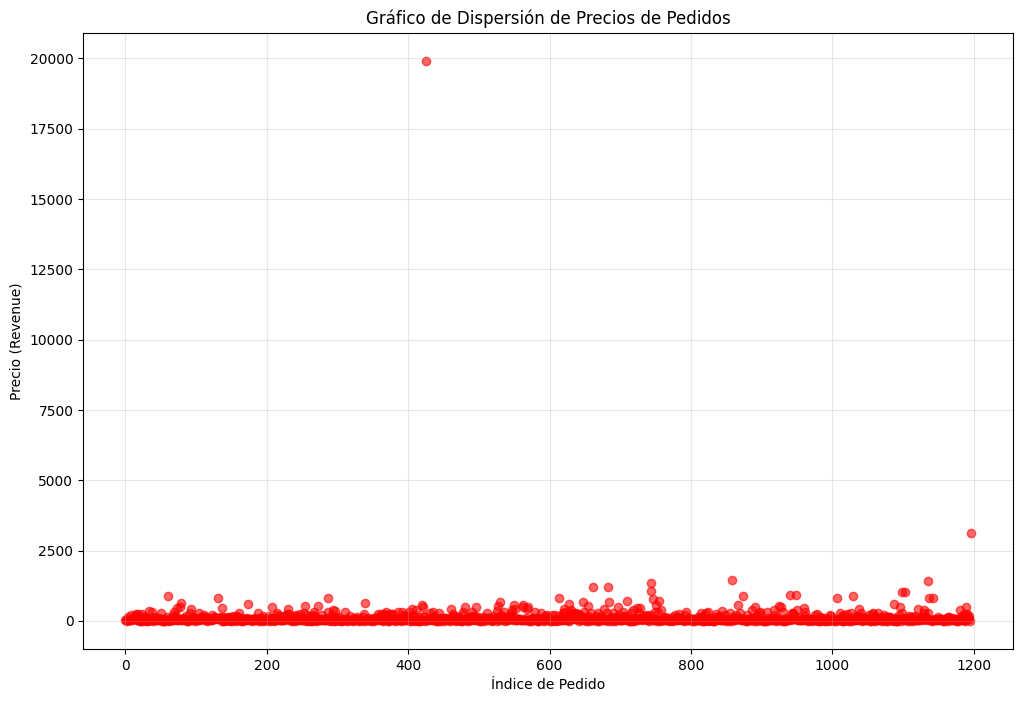

In [95]:
plt.figure(figsize=(12, 8))
plt.scatter(range(len(orders)), orders['revenue'], color='red', alpha=0.6)
plt.title('Gráfico de Dispersión de Precios de Pedidos')
plt.xlabel('Índice de Pedido')
plt.ylabel('Precio (Revenue)')
plt.grid(True, alpha=0.3)
plt.show()

##### Podemos ver que casi ningún pedido supera el precio de los 1000; una vez más tenemos el problema de que los usuarios realizan pedidos únicos y de bajo costo; tal vez esto indique que la página tenga algo que incite a las personas a solo realizar un pedido; si es así, es necesario cambiarlo.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La visualización y el análisis de las tasas de conversión y del comportamiento de pedidos por usuario están bien construidos y reflejan un razonamiento analítico sólido. Logras identificar patrones relevantes y explicar su posible impacto en el desempeño de la tienda.
</div>


### Percentiles 95 y 99 de los precios de los pedidos. y punto de anomalía.

In [96]:
percentile_95_price = np.percentile(orders['revenue'], 95)
percentile_99_price = np.percentile(orders['revenue'], 99)

print(f"Percentil 95 de precios: ${percentile_95_price:.2f}")
print(f"Percentil 99 de precios: ${percentile_99_price:.2f}")

Percentil 95 de precios: $435.54
Percentil 99 de precios: $900.90


In [97]:
price_anomaly_threshold = percentile_95_price

print(f"\nPunto de anomalía de precios definido en: ${price_anomaly_threshold:.2f}")

# Identificar pedidos con precios anómalos
anomalous_orders = orders[orders['revenue'] > price_anomaly_threshold]
print(f"\nNúmero de pedidos con precios anómalos (>${price_anomaly_threshold:.2f}): {len(anomalous_orders)}")
print(f"Porcentaje de pedidos con precios anómalos: {len(anomalous_orders)/len(orders)*100:.2f}%")

if len(anomalous_orders) > 0:
    print(f"\nPrimeros 10 pedidos con precios más altos:")
    print(anomalous_orders.sort_values('revenue', ascending=False)[['transactionid', 'revenue', 'group', 'date']].head(10))


Punto de anomalía de precios definido en: $435.54

Número de pedidos con precios anómalos (>$435.54): 60
Porcentaje de pedidos con precios anómalos: 5.01%

Primeros 10 pedidos con precios más altos:
      transactionid  revenue group       date
425       590470918  19920.4     B 2019-08-19
1196     3936777065   3120.1     B 2019-08-15
858       192721366   1450.2     A 2019-08-27
1136      666610489   1425.8     A 2019-08-13
744      3668308183   1335.6     B 2019-08-27
682      1216533772   1220.2     B 2019-08-29
662      1811671147   1220.2     A 2019-08-29
743      3603576309   1050.0     A 2019-08-09
1103     1348774318   1025.8     A 2019-08-12
1099      316924019   1015.9     A 2019-08-12


##### El percentil 95 y 99 es muy alto en precio; a comparación de los precios por debajo de estos, son significativos. Esto también tiene relación con los usuarios que suelen realizar pedidos constantes; esto nos indica que entre más piden, también más gastan. El punto de anomalía solo es del 5%; esto es un grave problema para las ventas; en general, necesitamos incentivarlas.

### Significancia estadística de la diferencia en la conversión entre los grupos

In [98]:
group_stats = conversion_data.groupby('group').agg({
    'visits': 'sum',
    'orders': 'sum'
}).reset_index()

visits_A = group_stats[group_stats['group'] == 'A']['visits'].iloc[0]
orders_A = group_stats[group_stats['group'] == 'A']['orders'].iloc[0]
visits_B = group_stats[group_stats['group'] == 'B']['visits'].iloc[0]
orders_B = group_stats[group_stats['group'] == 'B']['orders'].iloc[0]

p_A = orders_A / visits_A
p_B = orders_B / visits_B

print(f"Grupo A: {orders_A} conversiones de {visits_A} visitas (p = {p_A:.4f})")
print(f"Grupo B: {orders_B} conversiones de {visits_B} visitas (p = {p_B:.4f})")

group_stats['conversion_rate'] = (group_stats['orders'] / group_stats['visits']) * 100
print(f"Tasas de conversión totales:")
print(group_stats[['group', 'conversion_rate']])

Grupo A: 557 conversiones de 18736 visitas (p = 0.0297)
Grupo B: 640 conversiones de 18916 visitas (p = 0.0338)
Tasas de conversión totales:
  group  conversion_rate
0     A         2.972886
1     B         3.383379


##### Con esto podemos determinar que no hay una diferencia significativa en los datos para poder continuar con la prueba; analicemos los datos más a fondo para tomar la decisión.

### Significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos.

In [99]:
group_order_stats = orders.groupby('group')['revenue'].agg(['count', 'mean', 'std', 'median']).reset_index()

orders_A = orders[orders['group'] == 'A']['revenue']
orders_B = orders[orders['group'] == 'B']['revenue']

print(f"Grupo A: {len(orders_A)} pedidos, promedio: ${orders_A.mean():.2f}")
print(f"Grupo B: {len(orders_B)} pedidos, promedio: ${orders_B.mean():.2f}")
print(f"Diferencia absoluta: ${orders_B.mean() - orders_A.mean():.2f}")

Grupo A: 557 pedidos, promedio: $115.90
Grupo B: 640 pedidos, promedio: $145.06
Diferencia absoluta: $29.17


In [104]:
stat_A, p_val_A = shapiro(orders_A.sample(min(5000, len(orders_A))))
stat_B, p_val_B = shapiro(orders_B.sample(min(5000, len(orders_B))))
print(f"Grupo A - Shapiro p-value: {p_val_A:.10f}")
print(f"Grupo B - Shapiro p-value: {p_val_B:.10f}")

t_stat, p_value = stats.ttest_ind(orders_A, orders_B, equal_var=False)

print("PRUEBA T DE STUDENT - TAMAÑO PROMEDIO DE PEDIDO")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Nivel de significancia (α): 0.05")

Grupo A - Shapiro p-value: 0.0000000000
Grupo B - Shapiro p-value: 0.0000000000
PRUEBA T DE STUDENT - TAMAÑO PROMEDIO DE PEDIDO
Estadístico t: -0.8886
Valor p: 0.374507
Nivel de significancia (α): 0.05


##### Los datos no muestran una significancia que valga la pena tener en cuenta; necesitamos seguir con la prueba para verificar y poder terminarla. Los pedidos sí muestran una diferencia; son casi 100 más del grupo B y la diferencia muestra un ingreso a tener en cuenta.

##### Es difícil decir por qué el patrón de compra en grupo B es mayor y por qué suelen gastar mas, podriamos crear un dataframe que tenga datos de los usuarios para asi poder determinar el porque de esto.

### Significancia estadística de la diferencia en la conversión entre los grupos (Datos Filtrados)

In [108]:
counts = np.array([557, 640])  
nobs = np.array([18736, 18916 ])    

print("Datos preparados:")
print(f"Conversiones: {counts}")
print(f"Visitas totales: {nobs}")

Datos preparados:
Conversiones: [557 640]
Visitas totales: [18736 18916]


In [109]:
z_stat, p_value = proportions_ztest(counts, nobs)

print("PRUEBA Z DE PROPORCIONES")
print(f"Estadístico Z: {z_stat:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Nivel de significancia (α): 0.05")

PRUEBA Z DE PROPORCIONES
Estadístico Z: -2.2700
Valor p: 0.023207
Nivel de significancia (α): 0.05


##### Podemos concluir que los datos son sólidos y no hay ninguna casualidad, y podemos decir que la tasa de conversión del grupo B es mayor, como ya habíamos observado.

In [114]:
orders_A_filtered = orders[(orders['group'] == 'A') & (orders['revenue'] <= percentile_95_price)]
orders_B_filtered = orders[(orders['group'] == 'B') & (orders['revenue'] <= percentile_95_price)]

avg_order_A = orders_A_filtered['revenue'].mean()
avg_order_B = orders_B_filtered['revenue'].mean()

print("ESTADÍSTICAS DESCRIPTIVAS ")
print(f"Grupo A - Tamaño de muestra: {len(orders_A_filtered)}")
print(f"Grupo A - Desviación estándar: ${orders_A_filtered['revenue'].std():.2f}")
print(f"Grupo B - Tamaño de muestra: {len(orders_B_filtered)}")
print(f"Grupo B - Desviación estándar: ${orders_B_filtered['revenue'].std():.2f}")

ESTADÍSTICAS DESCRIPTIVAS 
Grupo A - Tamaño de muestra: 531
Grupo A - Desviación estándar: $90.45
Grupo B - Tamaño de muestra: 606
Grupo B - Desviación estándar: $89.18


In [118]:
t_stat, p_value = ttest_ind(orders_A_filtered['revenue'], orders_B_filtered['revenue'])

print("PRUEBA T DE STUDENT")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Nivel de significancia (α): 0.05")

PRUEBA T DE STUDENT
Estadístico t: 0.2502
Valor p: 0.802478
Nivel de significancia (α): 0.05


##### Podemos ver que no hay una diferencia significativa en los datos; esto indica que las medidas de los grupos son similares; lo que podemos concluir es que el grupo B tiene mejor tasa de conversión.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - Integras de manera clara las pruebas estadísticas y su interpretación, mostrando buen criterio al contrastar conversiones y tamaños de pedido. Tu análisis conserva coherencia y solidez a lo largo de toda la sección.
</div>


## Conclusion

##### Con estos datos podemos observar que los datos filtrados para las conversiones de pedidos son algo significativos; es de 0.41 puntos más que el grupo A; en el tamaño promedio del pedido no hay nada significativo, no hay mucha diferencia en el número promedio. Podemos ver que el grupo B tiene una mejora relativa del 13.8%; esto da mejores resultados en la conversión de pedidos.

##### Con esto podemos concluir que la mejor decisión es concluir con la prueba, ya que no hay datos para pensar que habrá efectos negativos; solo podemos concluir que tendremos efectos positivos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - Tu conclusión resume de forma clara los hallazgos clave y mantiene coherencia con todo el análisis previo. Logras sintetizar correctamente la evidencia y plantear una decisión final bien fundamentada.
</div>


# Comentario General del Revisor

<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a>  

    
Tu proyecto muestra un desarrollo analítico consistente y una lectura madura de los datos del experimento A/B. Lograste integrar limpieza, exploración, priorización de hipótesis y pruebas estadísticas con un hilo lógico sólido. A lo largo del trabajo mantuviste claridad metodológica y una interpretación responsable de los resultados.

### Puntos Positivos:

* **Preparación y organización de datos:** La estandarización de columnas, el tratamiento de fechas y la verificación de estructuras demuestran atención al detalle y una base técnica bien aplicada.
* **Exploración y visualización:** Tus gráficos acumulados, tasas de conversión y dispersión aportan una lectura clara del comportamiento de los usuarios y fortalecen tus conclusiones.
* **Análisis estadístico:** Aplicaste adecuadamente ICE, RICE, pruebas de proporciones, pruebas t y detección de anomalías, mostrando criterio para interpretar diferencias y significancia.
* **Conclusión fundamentada:** La decisión final se apoya en evidencia y mantiene coherencia con todo el proceso analítico.

Has conseguido un proyecto sólido y bien argumentado, reflejando un progreso notable en tu manejo de análisis experimentales y métricas de negocio. Continúa perfeccionando esta línea de trabajo con la misma claridad y dedicación mostrada aquí.

</div>
